In [1]:
# Install all required packages
!pip install -q datasets tiktoken wandb tqdm matplotlib numpy torch


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from dataclasses import dataclass
from contextlib import nullcontext
from tqdm.auto import tqdm

# WandB for experiment tracking (set USE_WANDB=False to skip)
USE_WANDB = True
try:
    import wandb
except ImportError:
    USE_WANDB = False
    print("wandb not found — install with: pip install wandb")

torch.manual_seed(42)
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")


/home/btech02_06/DL/MML_lab_VU_-main/data/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.11.0+cu130
CUDA available  : True
GPU             : NVIDIA RTX 4000 Ada Generation


In [3]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")
print(ds)


Generating train split: 100%|█| 2119719/2119719 [00:02<00:00, 1037249.76 example
Generating validation split: 100%|█| 21990/21990 [00:00<00:00, 1176078.05 exampl

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})


In [4]:
import tiktoken
from tqdm.auto import tqdm

enc = tiktoken.get_encoding("gpt2")

def process(example):
    ids = enc.encode_ordinary(example['text'])
    return {'ids': ids, 'len': len(ids)}

if not os.path.exists("train.bin"):
    print("Tokenizing dataset... (first run only)")
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="Tokenizing",
        num_proc=4,
    )
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        arr = np.memmap(filename, dtype=np.uint16, mode='w+', shape=(arr_len,))
        total_batches = 1024
        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'Writing {filename}'):
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()
    print("✅ Tokenization complete")
else:
    print("✅ Token files already exist — skipping tokenization")


Tokenizing dataset... (first run only)


Tokenizing (num_proc=4): 100%|█| 2119719/2119719 [00:26<00:00, 78938.63 examples
Writing validation.bin: 100%|██████████████| 1024/1024 [00:03<00:00, 302.61it/s]

✅ Tokenization complete


In [5]:
def get_batch(split, block_size, batch_size, device, device_type):
    """Load a random batch from memory-mapped token files."""
    fname = 'train.bin' if split == 'train' else 'validation.bin'
    data = np.memmap(fname, dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i+block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+block_size].astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


In [6]:
# ══════════════════════════════════════════════════════════════
#  UPGRADE 1 — RMSNorm
# ══════════════════════════════════════════════════════════════
class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization.
    Faster than LayerNorm: no mean subtraction, no bias term.
    Paper: https://arxiv.org/abs/1910.07467
    """
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight


# ══════════════════════════════════════════════════════════════
#  UPGRADE 2 — Rotary Positional Embeddings (RoPE)
# ══════════════════════════════════════════════════════════════
def precompute_freqs_cis(head_dim: int, max_seq_len: int, theta: float = 10000.0, device='cpu'):
    """
    Precompute complex exponentials for RoPE.
    Returns tensor of shape (max_seq_len, head_dim // 2) as complex numbers.
    """
    assert head_dim % 2 == 0, "head_dim must be even for RoPE"
    freqs = 1.0 / (theta ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
    t = torch.arange(max_seq_len, device=device)
    freqs = torch.outer(t, freqs)                      # (T, head_dim/2)
    freqs_cis = torch.polar(torch.ones_like(freqs), freqs)  # complex plane
    return freqs_cis


def apply_rotary_emb(xq: torch.Tensor, xk: torch.Tensor, freqs_cis: torch.Tensor):
    """
    Apply rotary embeddings to Q and K.
    xq, xk: (B, T, n_head, head_dim)
    freqs_cis: (T, head_dim//2) complex
    Returns: xq_rotated, xk_rotated — same shapes as input
    """
    def rotate(x):
        # Reshape to complex: (..., head_dim) -> (..., head_dim/2, 2) -> complex
        x_c = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2))
        # Broadcast freqs_cis over batch and head dims
        fc = freqs_cis.view(1, x_c.shape[1], 1, x_c.shape[-1])  # (1, T, 1, head_dim/2)
        x_rot = torch.view_as_real(x_c * fc).flatten(-2)
        return x_rot.type_as(x)

    return rotate(xq), rotate(xk)


print("✅ RMSNorm and RoPE defined")


✅ RMSNorm and RoPE defined


In [7]:
# ══════════════════════════════════════════════════════════════
#  UPGRADE 3 — SwiGLU Feed-Forward Network
# ══════════════════════════════════════════════════════════════
class SwiGLU(nn.Module):
    """
    SwiGLU activation: output = SiLU(xW1) ⊙ (xW3), then projected down by W2.

    Hidden dimension is set to (8/3) * n_embd, rounded to multiple of 64.
    This keeps parameter count comparable to a standard 4x GELU MLP.

    Paper: GLU Variants Improve Transformer (Noam Shazeer, 2020)
    Used in: LLaMA 1/2/3, PaLM, Mistral, Gemma
    """
    def __init__(self, config):
        super().__init__()
        # (8/3) * n_embd ≈ 2.67 * n_embd; rounded to nearest 64 for hardware efficiency
        hidden = int(8 * config.n_embd / 3)
        hidden = (hidden + 63) // 64 * 64

        self.w1 = nn.Linear(config.n_embd, hidden, bias=False)   # gate
        self.w3 = nn.Linear(config.n_embd, hidden, bias=False)   # up
        self.w2 = nn.Linear(hidden, config.n_embd, bias=False)   # down
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        # Gated: SiLU(gate) * up, then projected down
        return self.dropout(self.w2(F.silu(self.w1(x)) * self.w3(x)))


print("✅ SwiGLU defined")


✅ SwiGLU defined


In [8]:
# ══════════════════════════════════════════════════════════════
#  Causal Self-Attention with RoPE
# ══════════════════════════════════════════════════════════════
class CausalSelfAttentionRoPE(nn.Module):
    """
    Multi-head causal self-attention with:
    - Separate Q, K, V linear projections (no bias — LLaMA style)
    - Rotary Positional Embeddings applied to Q and K
    - Flash Attention via F.scaled_dot_product_attention when available
    - Manual attention fallback with optional weight saving for visualization
    """
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0

        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.head_dim = config.n_embd // config.n_head

        # Separate projections (no bias — cleaner, LLaMA/Mistral style)
        self.q_proj = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.k_proj = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.v_proj = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.out_proj = nn.Linear(config.n_embd, config.n_embd, bias=False)

        self.attn_dropout_p = config.dropout
        self.resid_dropout = nn.Dropout(config.dropout)

        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            # Fallback causal mask for older PyTorch
            self.register_buffer(
                "causal_mask",
                torch.tril(torch.ones(config.block_size, config.block_size))
                     .view(1, 1, config.block_size, config.block_size)
            )

        self.saved_attn_weights = None  # for visualization

    def forward(self, x, freqs_cis, save_attn: bool = False):
        B, T, C = x.size()

        # Project Q, K, V
        q = self.q_proj(x).view(B, T, self.n_head, self.head_dim)  # (B, T, H, D)
        k = self.k_proj(x).view(B, T, self.n_head, self.head_dim)
        v = self.v_proj(x).view(B, T, self.n_head, self.head_dim)

        # Apply RoPE to Q and K
        q, k = apply_rotary_emb(q, k, freqs_cis)

        # Transpose to (B, H, T, D) for attention computation
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        if self.flash and not save_attn:
            # Flash Attention — O(N) memory, fastest path
            y = F.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.attn_dropout_p if self.training else 0.0,
                is_causal=True,
            )
            self.saved_attn_weights = None
        else:
            # Manual attention — needed when saving weights for visualization
            scale = 1.0 / math.sqrt(self.head_dim)
            att = (q @ k.transpose(-2, -1)) * scale            # (B, H, T, T)
            if hasattr(self, 'causal_mask'):
                att = att.masked_fill(self.causal_mask[:, :, :T, :T] == 0, float('-inf'))
            else:
                causal_mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
                att = att.masked_fill(causal_mask == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            if save_attn:
                self.saved_attn_weights = att.detach().cpu()   # store for viz
            att = F.dropout(att, p=self.attn_dropout_p, training=self.training)
            y = att @ v

        # Merge heads and project
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.out_proj(y))
        return y


print("✅ CausalSelfAttentionRoPE defined")


✅ CausalSelfAttentionRoPE defined


In [9]:
# ══════════════════════════════════════════════════════════════
#  Transformer Block
# ══════════════════════════════════════════════════════════════
class Block(nn.Module):
    """
    Pre-norm Transformer block: RMSNorm → Attention → RMSNorm → SwiGLU.
    Pre-norm (vs post-norm in original GPT-2) improves training stability
    and is used in all modern LLMs.
    """
    def __init__(self, config):
        super().__init__()
        self.ln1  = RMSNorm(config.n_embd)
        self.attn = CausalSelfAttentionRoPE(config)
        self.ln2  = RMSNorm(config.n_embd)
        self.mlp  = SwiGLU(config)

    def forward(self, x, freqs_cis, save_attn=False):
        x = x + self.attn(self.ln1(x), freqs_cis, save_attn=save_attn)
        x = x + self.mlp(self.ln2(x))
        return x


# ══════════════════════════════════════════════════════════════
#  Model Config
# ══════════════════════════════════════════════════════════════
@dataclass
class SLMConfig:
    block_size : int   = 128     # context / sequence length
    vocab_size : int   = 50257   # GPT-2 tokenizer vocab
    n_layer    : int   = 6       # number of transformer blocks
    n_head     : int   = 6       # attention heads
    n_embd     : int   = 384     # embedding dimension
    dropout    : float = 0.1
    rope_theta : float = 10000.0 # RoPE base frequency


# ══════════════════════════════════════════════════════════════
#  Full SLM Model
# ══════════════════════════════════════════════════════════════
class SLM(nn.Module):
    """
    Advanced Small Language Model with:
    - No learned positional embeddings (RoPE handles position)
    - RMSNorm (pre-norm)
    - SwiGLU MLP
    - Flash Attention + RoPE in self-attention
    - Weight-tied embedding / LM head
    - Built-in top-k, top-p and beam search generation
    """
    def __init__(self, config: SLMConfig):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),   # token embedding
            drop = nn.Dropout(config.dropout),
            h   = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = RMSNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Weight tying: token embedding == LM head weights
        self.transformer.wte.weight = self.lm_head.weight

        # Precompute and register RoPE frequencies as a non-parameter buffer
        head_dim = config.n_embd // config.n_head
        self.register_buffer(
            "freqs_cis",
            precompute_freqs_cis(head_dim, config.block_size, config.rope_theta)
        )

        # Weight initialization
        self.apply(self._init_weights)
        # Scaled init for residual projections (GPT-2 paper §2.3)
        for name, p in self.named_parameters():
            if name.endswith('out_proj.weight') or name.endswith('w2.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    # ──────────────────────────────────────────────────────────
    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def parameter_breakdown(self) -> dict:
        """Returns parameter count per component group."""
        groups = {"embeddings": 0, "attention": 0, "mlp": 0, "norms": 0, "lm_head": 0}
        for name, p in self.named_parameters():
            n = p.numel()
            if 'wte' in name or 'wpe' in name:
                groups["embeddings"] += n
            elif any(x in name for x in ['q_proj', 'k_proj', 'v_proj', 'out_proj']):
                groups["attention"] += n
            elif any(x in name for x in ['w1', 'w2', 'w3', 'c_fc', 'c_proj', 'mlp']):
                groups["mlp"] += n
            elif any(x in name for x in ['ln', 'norm', 'weight']) and 'embed' not in name and 'head' not in name:
                groups["norms"] += n
            elif 'lm_head' in name:
                groups["lm_head"] += n
        return groups

    # ──────────────────────────────────────────────────────────
    def forward(self, idx, targets=None, save_attn=False):
        B, T = idx.size()
        assert T <= self.config.block_size, f"Sequence length {T} exceeds block_size {self.config.block_size}"

        freqs_cis = self.freqs_cis[:T]   # slice to current sequence length

        x = self.transformer.drop(self.transformer.wte(idx))  # token embed only — no pos embed

        for block in self.transformer.h:
            x = block(x, freqs_cis, save_attn=save_attn)

        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss   = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1,
            )
            return logits, loss
        else:
            # During inference: only compute logit for the last position
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    # ──────────────────────────────────────────────────────────
    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
        """
        Autoregressive text generation with configurable decoding strategy.

        Args:
            idx:            (B, T) input token tensor
            max_new_tokens: number of tokens to generate
            temperature:    1.0 = default; <1 = sharper; >1 = more random
            top_k:          keep only top-k tokens before sampling
            top_p:          nucleus sampling — keep tokens covering top_p probability mass
        """
        self.eval()
        for _ in range(max_new_tokens):
            # Crop to block_size if needed
            idx_cond = idx[:, -self.config.block_size:]

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature   # (B, vocab_size)

            # ── Top-k filtering ────────────────────────────────
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')

            probs = F.softmax(logits, dim=-1)

            # ── Top-p (Nucleus) filtering ──────────────────────
            if top_p is not None and top_p < 1.0:
                sorted_probs, sorted_indices = torch.sort(probs, descending=True)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
                # Remove tokens beyond the nucleus
                sorted_remove = cumulative_probs - sorted_probs > top_p
                sorted_remove[..., 0] = False   # always keep the most probable token
                indices_to_remove = sorted_remove.scatter(1, sorted_indices, sorted_remove)
                probs[indices_to_remove] = 0.0
                probs = probs / probs.sum(dim=-1, keepdim=True)  # renormalize

            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx

    # ──────────────────────────────────────────────────────────
    @torch.no_grad()
    def beam_search(self, idx, max_new_tokens, beam_width=4):
        """
        Beam search decoding — deterministic, higher quality output.
        Maintains beam_width candidate sequences and picks the best.

        Args:
            idx:            (1, T) input tensor — batch size MUST be 1
            max_new_tokens: number of tokens to generate
            beam_width:     number of parallel beams to maintain
        Returns:
            best_seq: (1, T + max_new_tokens) tensor with best decoded sequence
        """
        assert idx.size(0) == 1, "Beam search requires batch size 1"
        self.eval()
        device = idx.device

        beams = [(0.0, idx)]   # list of (cumulative_log_prob, sequence_tensor)

        for step in range(max_new_tokens):
            all_candidates = []

            for score, seq in beams:
                seq_cond = seq[:, -self.config.block_size:]
                logits, _ = self(seq_cond)
                log_probs = F.log_softmax(logits[:, -1, :], dim=-1)

                top_log_probs, top_ids = torch.topk(log_probs, beam_width)

                for i in range(beam_width):
                    new_score = score + top_log_probs[0, i].item()
                    new_seq   = torch.cat([seq, top_ids[:, i:i+1]], dim=1)
                    all_candidates.append((new_score, new_seq))

            # Keep top beam_width by score (normalized by length for fairness)
            all_candidates.sort(key=lambda x: x[0] / (x[1].size(1) + 1e-8), reverse=True)
            beams = all_candidates[:beam_width]

        best_score, best_seq = beams[0]
        return best_seq


print("✅ Block, SLMConfig, SLM model defined")


✅ Block, SLMConfig, SLM model defined


In [10]:
config = SLMConfig(
    vocab_size  = 50257,
    block_size  = 128,
    n_layer     = 6,
    n_head      = 6,
    n_embd      = 384,
    dropout     = 0.1,
    rope_theta  = 10000.0,
)

model = SLM(config)

# ── Detailed parameter breakdown ──────────────────────────────
total_params = model.count_parameters()
breakdown    = model.parameter_breakdown()

print("\n" + "="*50)
print("       MODEL PARAMETER BREAKDOWN")
print("="*50)
for component, count in breakdown.items():
    bar = "█" * int(count / total_params * 40)
    print(f"  {component:<14} {count:>10,}  {bar}")
print("-"*50)
print(f"  {'TOTAL':<14} {total_params:>10,}")
print("="*50)
print(f"\n  Architecture : {config.n_layer}L × {config.n_head}H × {config.n_embd}D")
print(f"  Context len  : {config.block_size} tokens")
print(f"  Norm type    : RMSNorm")
print(f"  MLP type     : SwiGLU")
print(f"  Pos encoding : RoPE (θ = {config.rope_theta})")
print(f"  Weight tying : embedding ↔ LM head")



       MODEL PARAMETER BREAKDOWN
  embeddings     19,298,688  █████████████████████████
  attention       3,538,944  ████
  mlp             7,077,888  █████████
  norms               4,992  
  lm_head                 0  
--------------------------------------------------
  TOTAL          29,920,512

  Architecture : 6L × 6H × 384D
  Context len  : 128 tokens
  Norm type    : RMSNorm
  MLP type     : SwiGLU
  Pos encoding : RoPE (θ = 10000.0)
  Weight tying : embedding ↔ LM head


In [11]:
def estimate_loss(model, config, eval_iters, batch_size, block_size, device, device_type, ctx):
    """Evaluate model on train and validation splits. Returns loss and perplexity."""
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split, block_size, batch_size, device, device_type)
                with ctx:
                    _, loss = model(X, Y)
                losses[k] = loss.item()
            avg_loss = losses.mean().item()
            out[split] = {
                'loss'        : avg_loss,
                'perplexity'  : math.exp(avg_loss),
            }
    model.train()
    return out


In [12]:
# ── Hyperparameters ──────────────────────────────────────────
learning_rate              = 1e-4
max_iters                  = 20000
warmup_steps               = 1000
min_lr                     = 1e-5
eval_iters                 = 200
eval_interval              = 500
batch_size                 = 32
block_size                 = 128
gradient_accumulation_steps = 32
max_grad_norm              = 1.0

# ── Device Setup ──────────────────────────────────────────────
device      = "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu'
dtype       = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype     = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx         = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

print(f"Device : {device} ({dtype})")

# ── Move model to device ──────────────────────────────────────
model = model.to(device)

# ── Gradient Checkpointing (optional — trades compute for memory) ──
USE_GRAD_CKPT = False   # set True on low-VRAM GPUs
if USE_GRAD_CKPT:
    from torch.utils.checkpoint import checkpoint_sequential
    print("Gradient checkpointing ENABLED")

# ── WandB Initialization ──────────────────────────────────────
if USE_WANDB:
    wandb.init(
        project = "advanced-slm",
        name    = f"SLM_RoPE_RMSNorm_SwiGLU_{config.n_layer}L_{config.n_embd}D",
        config  = {
            "architecture"  : "GPT-LLaMA-style",
            "n_layer"       : config.n_layer,
            "n_head"        : config.n_head,
            "n_embd"        : config.n_embd,
            "block_size"    : config.block_size,
            "vocab_size"    : config.vocab_size,
            "total_params"  : model.count_parameters(),
            "learning_rate" : learning_rate,
            "max_iters"     : max_iters,
            "batch_size"    : batch_size,
            "grad_accum"    : gradient_accumulation_steps,
            "dtype"         : dtype,
            "rope_theta"    : config.rope_theta,
            "norm"          : "RMSNorm",
            "mlp"           : "SwiGLU",
            "pos_enc"       : "RoPE",
        },
    )
    print("✅ WandB initialized")
else:
    print("WandB disabled — set USE_WANDB = True to enable tracking")


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

Device : cuda (bfloat16)
 cuda


wandb: WARNING Invalid choice
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


✅ WandB initialized


In [13]:
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = learning_rate,
    betas        = (0.9, 0.95),   # beta2=0.95 for LLM training (Chinchilla)
    weight_decay = 0.1,
    eps          = 1e-9,
)

# Linear warmup: lr goes from ~0 → learning_rate over warmup_steps
scheduler_warmup = LinearLR(optimizer, start_factor=0.01, total_iters=warmup_steps)

# Cosine decay: lr decays from learning_rate → min_lr
scheduler_decay  = CosineAnnealingLR(optimizer, T_max=max_iters - warmup_steps, eta_min=min_lr)

# Chain warmup → decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay],
                         milestones=[warmup_steps])

# Mixed precision gradient scaler (only needed for float16, not bfloat16)
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

print("✅ Optimizer and scheduler ready")
print(f"  Warmup : {warmup_steps} steps")
print(f"  Decay  : {max_iters - warmup_steps} steps (cosine)")
print(f"  Min LR : {min_lr}")


✅ Optimizer and scheduler ready
  Warmup : 1000 steps
  Decay  : 19000 steps (cosine)
  Min LR : 1e-05


/tmp/ipykernel_11779/1833850076.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


In [14]:
best_val_loss        = float('inf')
best_model_path      = "best_slm_params.pt"
train_losses         = []
val_losses           = []
val_perplexities     = []
lr_history           = []

model.train()

for step in tqdm(range(max_iters), desc="Training"):
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    # ── Evaluation checkpoint ──────────────────────────────
    if step % eval_interval == 0 and step > 0:
        metrics = estimate_loss(model, config, eval_iters, batch_size, block_size, device, device_type, ctx)

        t_loss = metrics['train']['loss']
        v_loss = metrics['val']['loss']
        v_ppl  = metrics['val']['perplexity']

        train_losses.append(t_loss)
        val_losses.append(v_loss)
        val_perplexities.append(v_ppl)

        print(f"\nStep {step:>6} | Train loss: {t_loss:.4f} | Val loss: {v_loss:.4f} | Val PPL: {v_ppl:.2f} | LR: {current_lr:.2e}")

        if USE_WANDB:
            wandb.log({
                "train/loss"       : t_loss,
                "val/loss"         : v_loss,
                "val/perplexity"   : v_ppl,
                "train/lr"         : current_lr,
                "train/step"       : step,
            })

        # Save best model checkpoint
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save({
                'step'        : step,
                'model_state' : model.state_dict(),
                'optim_state' : optimizer.state_dict(),
                'config'      : config,
                'val_loss'    : best_val_loss,
            }, best_model_path)
            print(f"  💾 New best checkpoint saved (val_loss={best_val_loss:.4f})")

    # ── Forward + Backward ────────────────────────────────
    X, y = get_batch('train', block_size, batch_size, device, device_type)

    with ctx:
        _, loss = model(X, y)
        loss = loss / gradient_accumulation_steps  # normalize for grad accumulation

    scaler.scale(loss).backward()

    # ── Gradient accumulation step ────────────────────────
    if (step + 1) % gradient_accumulation_steps == 0 or step + 1 == max_iters:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    scheduler.step()

if USE_WANDB:
    wandb.finish()

print("\n✅ Training complete!")
print(f"Best val loss : {best_val_loss:.4f} | Best val PPL : {math.exp(best_val_loss):.2f}")


Training:   0%|                                       | 0/20000 [00:00<?, ?it/s]/home/btech02_06/DL/MML_lab_VU_-main/data/myenv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Training:   3%|▋                          | 501/20000 [00:28<3:38:10,  1.49it/s]


Step    500 | Train loss: 9.8240 | Val loss: 9.8287 | Val PPL: 18558.42 | LR: 5.05e-05
  💾 New best checkpoint saved (val_loss=9.8287)


Training:   5%|█▍                           | 999/20000 [00:50<13:54, 22.78it/s]


Step   1000 | Train loss: 8.9515 | Val loss: 8.9567 | Val PPL: 7759.41 | LR: 1.00e-04


Training:   5%|█▎                        | 1005/20000 [00:56<2:36:03,  2.03it/s]

...

Training:  98%|██████████████████████████▎| 19505/20000 [18:35<04:08,  2.00it/s]

  💾 New best checkpoint saved (val_loss=3.0269)


Training: 100%|███████████████████████████| 20000/20000 [18:57<00:00, 17.59it/s]
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


train/loss,█▇▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,▄███████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train/step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
val/loss,█▇▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/perplexity,█▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,3.02687
train/lr,1e-05
train/step,19500
val/loss,3.02693
val/perplexity,20.6337



✅ Training complete!
Best val loss : 3.0269 | Best val PPL : 20.63


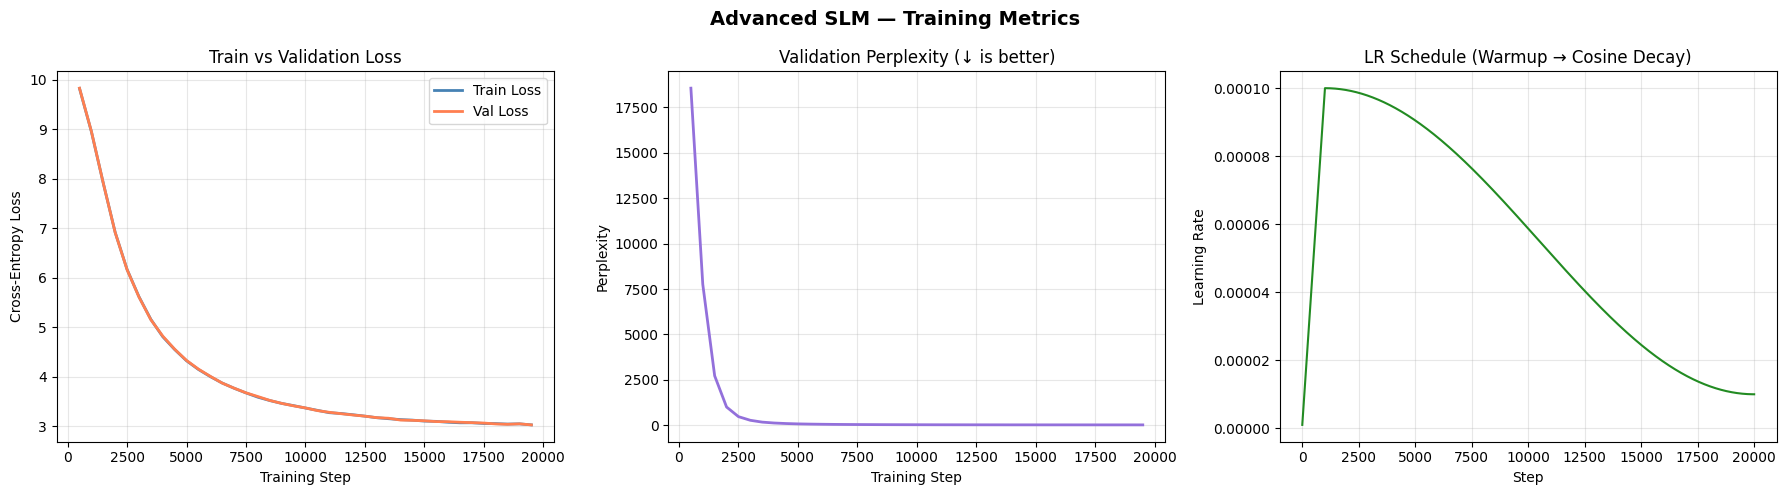

✅ Curves saved to slm_training_curves.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Advanced SLM — Training Metrics", fontsize=14, fontweight='bold')

eval_steps = list(range(eval_interval, max_iters, eval_interval))[:len(val_losses)]

# ── Loss curves ───────────────────────────────────────────────
ax = axes[0]
ax.plot(eval_steps, train_losses, 'steelblue', linewidth=2, label='Train Loss')
ax.plot(eval_steps, val_losses,   'coral',     linewidth=2, label='Val Loss')
ax.set_xlabel("Training Step"); ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Train vs Validation Loss"); ax.legend(); ax.grid(alpha=0.3)

# ── Perplexity curve ──────────────────────────────────────────
ax = axes[1]
ax.plot(eval_steps, val_perplexities, 'mediumpurple', linewidth=2)
ax.set_xlabel("Training Step"); ax.set_ylabel("Perplexity")
ax.set_title("Validation Perplexity (↓ is better)"); ax.grid(alpha=0.3)

# ── LR schedule ───────────────────────────────────────────────
ax = axes[2]
ax.plot(range(len(lr_history)), lr_history, 'forestgreen', linewidth=1.5)
ax.set_xlabel("Step"); ax.set_ylabel("Learning Rate")
ax.set_title("LR Schedule (Warmup → Cosine Decay)"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("slm_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curves saved to slm_training_curves.png")


In [19]:
checkpoint = torch.load("best_slm_params.pt", map_location=device, weights_only=False)

inf_config = checkpoint['config']
inf_model  = SLM(inf_config).to(device)
inf_model.load_state_dict(checkpoint['model_state'])
inf_model.eval()

print(f"✅ Loaded checkpoint from step {checkpoint['step']}")
print(f"   Val loss at save: {checkpoint['val_loss']:.4f}")
print(f"   Val PPL at save : {math.exp(checkpoint['val_loss']):.2f}")

✅ Loaded checkpoint from step 19500
   Val loss at save: 3.0269
   Val PPL at save : 20.63


In [20]:
def generate_text(model, enc, prompt, max_new_tokens=150, **kwargs):
    """Helper to encode prompt → generate → decode."""
    context = torch.tensor(enc.encode_ordinary(prompt), dtype=torch.long).unsqueeze(0).to(device)
    output  = model.generate(context, max_new_tokens=max_new_tokens, **kwargs)
    return enc.decode(output.squeeze().tolist())


prompt = "Once upon a time, there was a young rabbit who"

print("=" * 65)
print("PROMPT:", prompt)
print("=" * 65)

print("\n── GREEDY (temperature=0.1, top_k=1) ──────────────────────")
out = generate_text(inf_model, enc, prompt, temperature=0.1, top_k=1)
print(out)

print("\n── TOP-K (k=50, temperature=0.8) ──────────────────────────")
out = generate_text(inf_model, enc, prompt, top_k=50, temperature=0.8)
print(out)

print("\n── NUCLEUS / TOP-P (p=0.9, temperature=0.9) ───────────────")
out = generate_text(inf_model, enc, prompt, top_p=0.9, temperature=0.9)
print(out)

print("\n── TOP-K + TOP-P COMBINED (k=50, p=0.9, temp=0.85) ────────")
out = generate_text(inf_model, enc, prompt, top_k=50, top_p=0.9, temperature=0.85)
print(out)


PROMPT: Once upon a time, there was a young rabbit who

── GREEDY (temperature=0.1, top_k=1) ──────────────────────
Once upon a time, there was a young rabbit who loved to play in the park. One day, he saw a big, big tree. He wanted to play with it, but he didn't know what to do.

The boy was very sad and wanted to play with the bird. He asked his mom if he could go to the park. The boy said, "I'm sorry, mom. I'm sorry, but I'm sorry. I was not happy. I was not happy. I was not happy. I was not happy. I was not happy. I was not happy. I was not happy. I was not happy. I was not happy. I was not happy. I was sorry. I was sorry. I was sorry. I was sorry. I was sorry

── TOP-K (k=50, temperature=0.8) ──────────────────────────
Once upon a time, there was a young rabbit who loved to play with his friends. One day, Sam went to the park and said, "I'm very safe." But Lily wanted to watch the bird and help. She thought it was a good idea.

Lily said, "Yes, I can do that. Let's play with it."
